<a href="https://colab.research.google.com/github/SebastianD2/Lab_Biosenales/blob/main/Proyecto1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Bioseñales y Sistemas
##Primer proyecto
###Integrantes:
- Juan Sebastian Daza Betancourt
- Juan Jose Lopez Cuadros



#Consulta

###A. Descripción del Proyecto.
- El proyecto busca evaluar la factibilidad de sistemas Interfaz Cerebro-Computador (BCI) no invasivos mediante el análisis de señales de EEG de sujetos en cuatro estados: movimiento real (mano derecha/izquierda) e imaginación de movimiento (mano derecha/izquierda), además de periodos de reposo. Se centra en la identificación de patrones neurofisiológicos específicos que permitan traducir la intención motora en comandos digitales.
###B. Historia, Uso y Proyectos Futuros de BCIHistoria.
- Desde el descubrimiento del EEG por Hans Berger en 1924, el campo evolucionó hasta los años 70 con Jacques Vidal, quien acuñó el término "BCI". En los 90, se lograron las primeras comunicaciones básicas con pacientes con síndrome de enclaustramiento.
- Uso actual: Actualmente se hace uso principalmente en rehabilitación neuro-motora, comunicación asistiva y control de prótesis robóticas.
- Proyectos Futuros: Integración de BCI con Inteligencia Artificial para decodificación de lenguaje en tiempo real, "Neural Dust" (sensores microscópicos) y el uso de BCI en entornos de consumo (videojuegos y bienestar mental).
###C. Actividad Cerebral durante Movimiento e Imaginación
- El fenómeno clave es la Desincronización Relacionada con Eventos (ERD) y la Sincronización Relacionada con Eventos (ERS).
1. Electrodos de Interés: Según el sistema internacional 10-20, los electrodos sobre la corteza motora son críticos: C3 (mano derecha), C4 (mano izquierda) y Cz.
2. Ritmos Cerebrales:Ritmo Mu (8-13 Hz): Se atenúa (ERD) durante la ejecución o imaginación del movimiento en el hemisferio contralateral.Ritmo Beta (13-30 Hz): Presenta una disminución durante el movimiento y un aumento (rebote) al finalizar el mismo.

#Plan de análisis
Para evidenciar las diferencias entre las cuatro condiciones, se propone el siguiente flujo de procesamiento optimizado :

###1. Preprocesamiento (Acondicionamiento de la Señal)
- Remoción de Offset: Restar la media de la señal para centrarla en cero.
- Filtrado Pasa-Banda: Aplicar un filtro entre 8 Hz y 30 Hz. Este rango encapsula los ritmos Mu y Beta, eliminando ruido de baja frecuencia (movimientos oculares) y alta frecuencia (EMG o red eléctrica).
- Filtrado Notch : En caso de que persiste ruido de línea, aplicar un filtro en 60 Hz.
###2. Segmentación y Extracción de Características
- Segmentar la señal en épocas (epochs) correspondientes a los periodos de actividad (movimiento o imaginación) y reposo.
- Cálculo de Densidad Espectral de Potencia (PSD): Utilizar el método de Welch para estimar la potencia en las bandas de interés. La PSD permitirá observar cuantitativamente la caída de amplitud en Mu/Beta durante la intención motora comparada con el reposo.
###3. Análisis Estadístico y Comparativo
- Normalización: Escalar la potencia relativa de cada banda respecto a la potencia total para reducir la variabilidad entre sujetos.
- Comparación Espacial: Contrastar la potencia entre C3 y C4.

#Programación

In [ ]:
!pip install mne

In [ ]:
!pip install awscli

In [ ]:
!aws s3 sync --no-sign-request s3://openneuro.org/ds004362 /content/dataset_eeg

Archivos encontrados: 109

gráficas de ejemplo para S044
combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)


/tmp/ipykernel_26067/1372977659.py:47: RuntimeWarning: Cannot find channel coordinates in the supplied Evokeds. Not showing channel locations.
  mne.viz.plot_compare_evokeds(


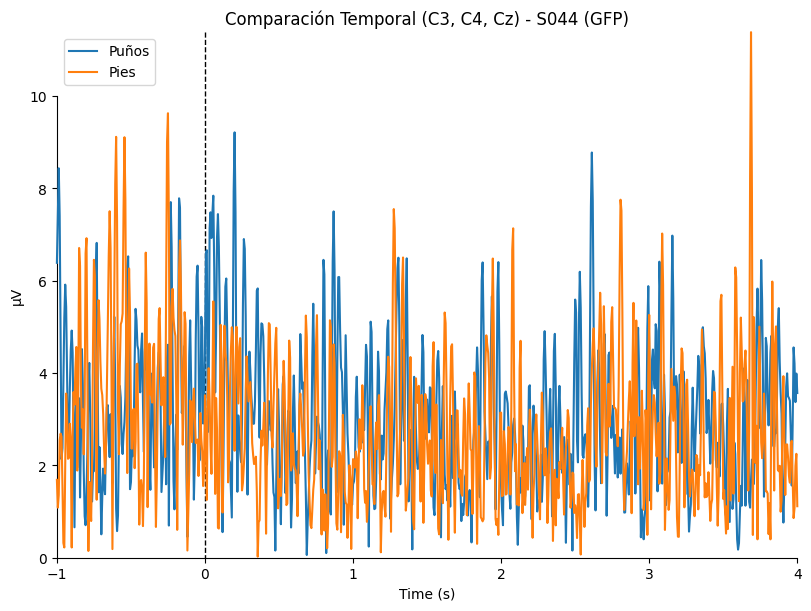

Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


/tmp/ipykernel_26067/1372977659.py:58: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  psd_punos_plot.plot(average=False, spatial_colors=True, axes=ax[0], show=False)
/tmp/ipykernel_26067/1372977659.py:60: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  psd_pies_plot.plot(average=False, spatial_colors=True, axes=ax[1], show=False)


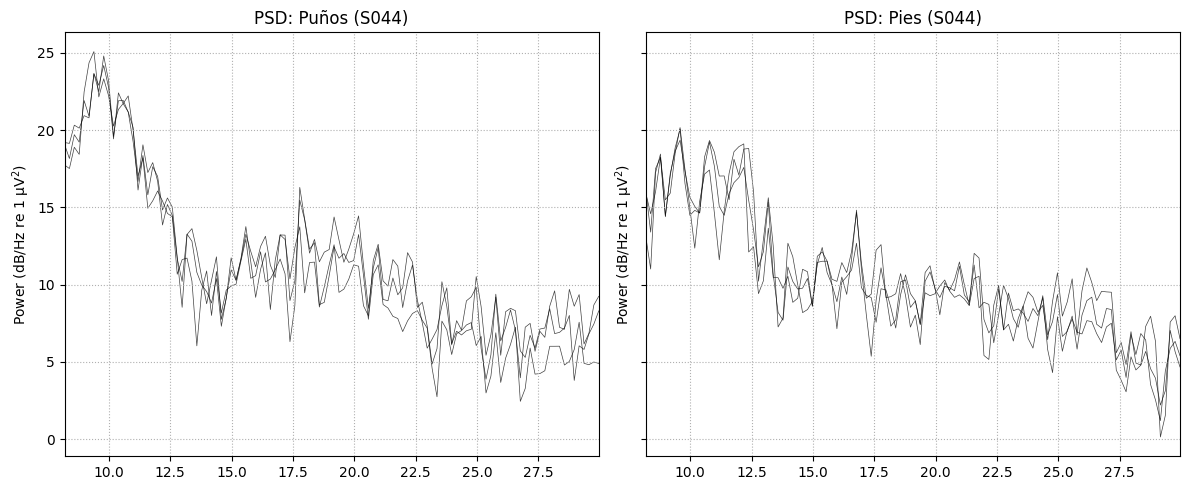

Gráficas mostradas.



/tmp/ipykernel_26067/1372977659.py:23: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(archivo_path, preload=True, verbose=False)


DATAFRAME


,Sujeto,Punos_Mu_C3,Punos_Mu_C4,Punos_Mu_Cz,Punos_Beta_C3,Punos_Beta_C4,Punos_Beta_Cz,Pies_Mu_C3,Pies_Mu_C4,Pies_Mu_Cz,Pies_Beta_C3,Pies_Beta_C4,Pies_Beta_Cz
0,S044,58.597343,62.512469,56.949091,35.903334,31.632859,38.376268,49.676791,50.042404,49.187206,43.995358,40.689649,43.050249
1,S040,31.685223,32.553873,32.647393,62.116439,61.261181,62.216522,31.796986,32.669678,35.434190,62.706664,63.410811,59.948591
2,S077,38.851844,36.230352,38.012573,55.256503,56.150711,55.214514,44.957302,47.047985,46.987534,46.184975,44.828106,45.452609
3,S069,29.406403,33.725425,33.263882,62.397615,59.434920,58.456714,27.861763,30.507714,32.562773,66.488557,65.231145,62.821740
4,S007,49.831451,49.810762,53.190270,44.034504,42.800515,39.934607,38.792887,43.069266,47.765131,41.306640,46.757317,40.014370


In [5]:
#HIPOTESIS 1: HAY DIFERENCIA ENTRE ABRIR Y CERRAR AMBOS PUÑOS O AMBOS PIES
#https://www.sciencedirect.com/science/article/pii/S1053811905025140
# la literatura dice que c3 y c4 a manos y cz pies.
import mne
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

ruta_dataset = Path("/content/dataset_eeg")
rutas_run5 = list(ruta_dataset.rglob('*R05.edf'))

print(f"Archivos encontrados: {len(rutas_run5)}")

# Lista para ir guardando los diccionarios con los resultados de cada paciente
datos_pacientes = []
grafica_mostrada = False

for archivo_path in rutas_run5:
    sujeto_id = archivo_path.stem.split('R')[0]

    try:
        raw = mne.io.read_raw_edf(archivo_path, preload=True, verbose=False)
        mapping = {ch: ch.replace('.', '').strip() for ch in raw.ch_names}
        raw.rename_channels(mapping)
        canales_interes = ['C3', 'C4', 'Cz']
        raw.pick(canales_interes)

        # Filtro pasabanda
        raw.filter(l_freq=6.0, h_freq=32.0, verbose=False)

        # Eventos y Épocas
        events, _ = mne.events_from_annotations(raw, event_id={'T0': 1, 'T1': 2, 'T2': 3}, verbose=False)
        epochs = mne.Epochs(raw, events, event_id=[2, 3], tmin=-1.0, tmax=4.0,
                            baseline=(None, 0), preload=True, verbose=False)

        epochs_punos = epochs['2']
        epochs_pies = epochs['3']

        # VISUALIZACIÓN (SOLO PARA EL PRIMER PACIENTE)
        if not grafica_mostrada:
            print(f"\ngráficas de ejemplo para {sujeto_id}")
            evoked_punos = epochs_punos.average()
            evoked_pies = epochs_pies.average()

            # Gráfica 1: Potenciales Evocados
            mne.viz.plot_compare_evokeds(
                dict(Puños=evoked_punos, Pies=evoked_pies),
                title=f'Comparación Temporal (C3, C4, Cz) - {sujeto_id}',
                show_sensors='upper right'
            )

            # Gráfica 2: PSD
            psd_punos_plot = epochs_punos.compute_psd(method='welch', fmin=8.0, fmax=30.0, verbose=False)
            psd_pies_plot = epochs_pies.compute_psd(method='welch', fmin=8.0, fmax=30.0, verbose=False)

            fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
            psd_punos_plot.plot(average=False, spatial_colors=True, axes=ax[0], show=False)
            ax[0].set_title(f'PSD: Puños ({sujeto_id})')
            psd_pies_plot.plot(average=False, spatial_colors=True, axes=ax[1], show=False)
            ax[1].set_title(f'PSD: Pies ({sujeto_id})')
            plt.tight_layout()
            plt.show()

            grafica_mostrada = True
            print("Gráficas mostradas.\n")

        # PSD RELATIVA
        psd_total_punos = epochs_punos.compute_psd(method='welch', fmin=8.0, fmax=30.0, verbose=False)
        psd_total_pies = epochs_pies.compute_psd(method='welch', fmin=8.0, fmax=30.0, verbose=False)

        datos_punos = psd_total_punos.get_data()
        datos_pies = psd_total_pies.get_data()
        frecuencias = psd_total_punos.freqs

        idx_mu = np.where((frecuencias >= 8.0) & (frecuencias <= 12.0))[0]
        idx_beta = np.where((frecuencias >= 13.0) & (frecuencias <= 30.0))[0]

        # Potencias Puños
        pot_mu_punos = np.sum(datos_punos[:, :, idx_mu], axis=2)
        pot_beta_punos = np.sum(datos_punos[:, :, idx_beta], axis=2)
        pot_total_punos = np.sum(datos_punos, axis=2)

        # Potencias Pies
        pot_mu_pies = np.sum(datos_pies[:, :, idx_mu], axis=2)
        pot_beta_pies = np.sum(datos_pies[:, :, idx_beta], axis=2)
        pot_total_pies = np.sum(datos_pies, axis=2)

        # Relativas y promedios Puños
        final_mu_punos = np.mean((pot_mu_punos / pot_total_punos) * 100, axis=0)
        final_beta_punos = np.mean((pot_beta_punos / pot_total_punos) * 100, axis=0)

        # Relativas y promedios Pies
        final_mu_pies = np.mean((pot_mu_pies / pot_total_pies) * 100, axis=0)
        final_beta_pies = np.mean((pot_beta_pies / pot_total_pies) * 100, axis=0)

        #GUARDAR EN DICCIONARIO
        datos_pacientes.append({
            'Sujeto': sujeto_id,
            'Punos_Mu_C3': final_mu_punos[0],
            'Punos_Mu_C4': final_mu_punos[1],
            'Punos_Mu_Cz': final_mu_punos[2],
            'Punos_Beta_C3': final_beta_punos[0],
            'Punos_Beta_C4': final_beta_punos[1],
            'Punos_Beta_Cz': final_beta_punos[2],
            'Pies_Mu_C3': final_mu_pies[0],
            'Pies_Mu_C4': final_mu_pies[1],
            'Pies_Mu_Cz': final_mu_pies[2],
            'Pies_Beta_C3': final_beta_pies[0],
            'Pies_Beta_C4': final_beta_pies[1],
            'Pies_Beta_Cz': final_beta_pies[2]
        })

    except Exception as e:
        print(f"  -> Error con {sujeto_id}: {e}")

print("DATAFRAME")
# Convertimos la lista de diccionarios a un DataFrame de Pandas
df_resultados = pd.DataFrame(datos_pacientes)

# Mostramos las primeras 5 filas para comprobar que todo esté bien
display(df_resultados.head())

Sujetos con datos R03 y R04 detectados: 109

--- Comparativa: Real vs Imaginado (Mano Derecha) - S001 ---
combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)


/tmp/ipykernel_26067/4149205415.py:61: RuntimeWarning: Cannot find channel coordinates in the supplied Evokeds. Not showing channel locations.
  mne.viz.plot_compare_evokeds(


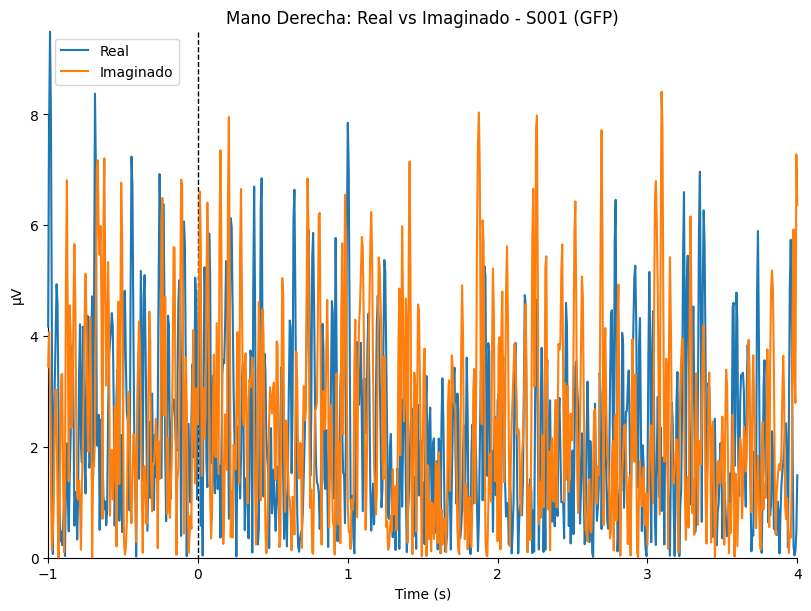

Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


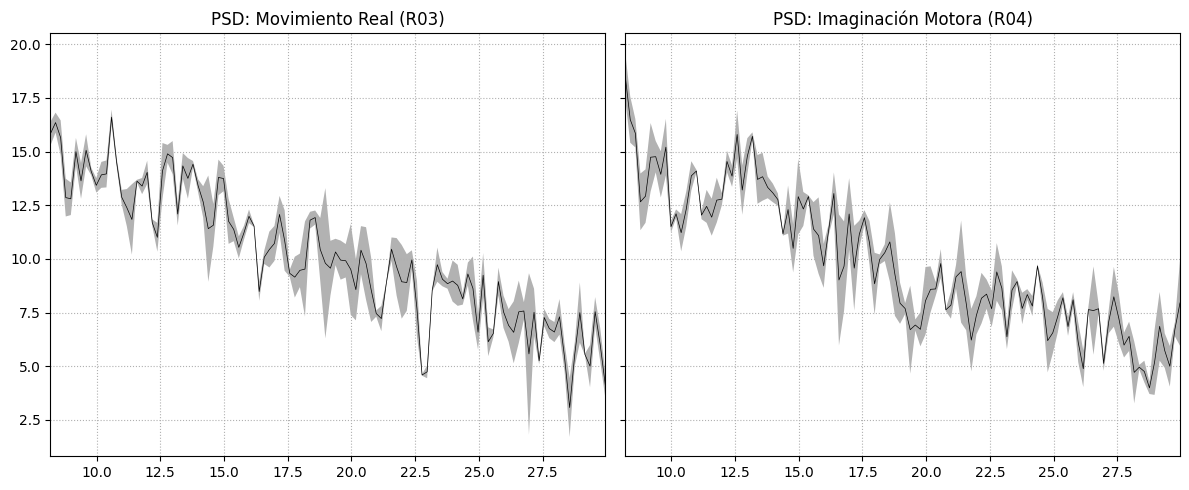

/tmp/ipykernel_26067/4149205415.py:37: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/tmp/ipykernel_26067/4149205415.py:37: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)


ANÁLISIS COMPLETADO


,Sujeto,Real_Mu_C3,Real_Mu_C4,Real_Beta_C3,Real_Beta_C4,Imag_Mu_C3,Imag_Mu_C4,Imag_Beta_C3,Imag_Beta_C4
0,S001,36.703845,35.918829,56.483889,55.434460,35.378524,37.205811,57.095787,51.418137
1,S002,34.442003,35.349452,58.891470,60.333032,31.607814,30.476026,60.786809,62.010414
2,S003,40.172022,35.284747,54.529641,58.146543,33.881732,30.153292,62.156554,66.172193
3,S004,31.169358,34.064090,63.316667,59.502986,26.633223,22.653051,68.451024,72.101044
4,S005,35.215065,30.269160,54.650886,64.301240,45.546880,36.747528,50.861368,57.966532


In [7]:
#HIPOTESIS 2: HAY DIFERENCIA ENTRE MOVER LA MANO DERECHA E IMAGINAR HACERLO
#la literatura nos dice que para manos son los canales c3 y c4, son los que analizaremos

import mne
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

ruta_dataset = Path("/content/dataset_eeg")

todos_los_r03 = list(ruta_dataset.rglob('*R03.edf'))
sujetos = sorted(list(set([p.parent.name for p in todos_los_r03])))

print(f"Sujetos con datos R03 y R04 detectados: {len(sujetos)}")

datos_comparativa = []
grafica_mostrada = False

for sujeto_id in sujetos:
    # Construimos las rutas buscando el archivo dentro de la carpeta del sujeto
    path_r03 = list(ruta_dataset.rglob(f"{sujeto_id}R03.edf"))
    path_r04 = list(ruta_dataset.rglob(f"{sujeto_id}R04.edf"))

    if not path_r03 or not path_r04:
        continue

    path_r03 = path_r03[0]
    path_r04 = path_r04[0]

    try:
        def procesar_raw(path):
            raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
            mapping = {ch: ch.replace('.', '').strip() for ch in raw.ch_names}
            raw.rename_channels(mapping)
            raw.pick(['C3', 'C4'])
            raw.filter(l_freq=6.0, h_freq=32.0, verbose=False)
            return raw

        raw_real = procesar_raw(path_r03)
        raw_imag = procesar_raw(path_r04)

        #EXTRACCIÓN DE ÉPOCAS (T2 = Mano Derecha
        def get_right_hand_epochs(raw):
            events, _ = mne.events_from_annotations(raw, event_id={'T2': 3}, verbose=False)
            return mne.Epochs(raw, events, event_id=3, tmin=-1.0, tmax=4.0,
                              baseline=(None, 0), preload=True, verbose=False)

        epochs_real = get_right_hand_epochs(raw_real)
        epochs_imag = get_right_hand_epochs(raw_imag)

        # VISUALIZACIÓN
        if not grafica_mostrada:
            print(f"\n--- Comparativa: Real vs Imaginado (Mano Derecha) - {sujeto_id} ---")

            # Temporal
            mne.viz.plot_compare_evokeds(
                dict(Real=epochs_real.average(), Imaginado=epochs_imag.average()),
                title=f'Mano Derecha: Real vs Imaginado - {sujeto_id}',
                show_sensors='upper right'
            )

            # Espectral (PSD)
            psd_real = epochs_real.compute_psd(method='welch', fmin=8, fmax=30, verbose=False)
            psd_imag = epochs_imag.compute_psd(method='welch', fmin=8, fmax=30, verbose=False)

            fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
            psd_real.plot(average=True, axes=ax[0], show=False)
            ax[0].set_title('PSD: Movimiento Real (R03)')
            psd_imag.plot(average=True, axes=ax[1], show=False)
            ax[1].set_title('PSD: Imaginación Motora (R04)')
            plt.tight_layout()
            plt.show()

            grafica_mostrada = True

        # --- CÁLCULO DE PSD RELATIVA ---
        def calcular_relativa(epochs):
            psd = epochs.compute_psd(method='welch', fmin=8, fmax=30, verbose=False)
            data = psd.get_data() # (épocas, canales, freqs)
            freqs = psd.freqs

            idx_mu = np.where((freqs >= 8) & (freqs <= 12))[0]
            idx_beta = np.where((freqs >= 13) & (freqs <= 30))[0]

            pot_mu = np.sum(data[:, :, idx_mu], axis=2)
            pot_beta = np.sum(data[:, :, idx_beta], axis=2)
            pot_total = np.sum(data, axis=2)


            rel_mu = np.mean((pot_mu / pot_total) * 100, axis=0)
            rel_beta = np.mean((pot_beta / pot_total) * 100, axis=0)
            return rel_mu, rel_beta

        mu_real, beta_real = calcular_relativa(epochs_real)
        mu_imag, beta_imag = calcular_relativa(epochs_imag)

        # --- GUARDAR DATOS ---
        datos_comparativa.append({
            'Sujeto': sujeto_id,
            'Real_Mu_C3': mu_real[0],
            'Real_Mu_C4': mu_real[1],
            'Real_Beta_C3': beta_real[0],
            'Real_Beta_C4': beta_real[1],
            'Imag_Mu_C3': mu_imag[0],
            'Imag_Mu_C4': mu_imag[1],
            'Imag_Beta_C3': beta_imag[0],
            'Imag_Beta_C4': beta_imag[1]
        })

    except Exception as e:
        print(f"  -> Error procesando {sujeto_id}: {e}")

df_comparativo = pd.DataFrame(datos_comparativa)
print("ANÁLISIS COMPLETADO")
display(df_comparativo.head())
